# <center> Recommender Systems</center>
## <center> Content Based Recommenders <br> MovieLens Movies Database </center>
<center>by: Nicole Woodland, P. Eng. for RoboGarden Inc. </center>

---
#### Ask the Right Question:

In this example, we have a database of Movies and information about them. <br> Can we use this data to make movies recommendations to the user?

### <font color='blue'> Download the Dataset </font>
Download the Dataset from the following link: <br>
https://www.kaggle.com/rounakbanik/the-movies-dataset?select=movies_metadata.csv

In [90]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

<font color = "blue"> Read the dataset into the Pandas Data Frame!

In [93]:
import pandas as pd
df = pd.read_csv("movies_metadata.csv")

# There are a few errors in the file, so the simplest thing to do it ignore those lines with the error_bad_lines option

In [6]:
df

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45461,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,NaN,0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
45462,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,2011-11-17,0.0,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0
45463,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,2003-08-01,0.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0
45464,False,NaN,0,[],NaN,227506,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",...,1917-10-21,0.0,87.0,[],Released,NaN,Satan Triumphant,False,0.0,0.0


In [7]:
df.describe()

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


In [8]:
len_metadata = len(df['id'].unique())
print(len_metadata)

45436


In [9]:
df.head(2).transpose()

,0,1
adult,False,False
belongs_to_collection,"{'id': 10194, 'name': 'Toy Story Collection', ...",NaN
budget,30000000,65000000
genres,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
homepage,http://toystory.disney.com/toy-story,NaN
id,862,8844
imdb_id,tt0114709,tt0113497
original_language,en,en
original_title,Toy Story,Jumanji
overview,"Led by Woody, Andy's toys live happily in his ...",When siblings Judy and Peter discover an encha...


### <font color = "blue"> Preprocessing - Applying TF-IDF
<font color = "blue"> Create a function named Content Based Recommender with TF-IDF and use it to recommend books based on content.
<br>
<br>
<font color = "black">
Fun fact! Hans Peter Luhn is credited for developing TF in 1957, and Karen Spärck Jones added to the concept with IDF in 1972, when it was put into practice first for document search and retireval.

https://www.historyofdatascience.com/karen-sparck-jones-the-search-engineer-enabler/


The Equation: 
$$
\text{TF-IDF}(t) \; = \; \frac{\text{frequency of term } t \; \text{in document}}{\text{number of terms in document}} \times \log{10}(\frac{\text{total number of documents }} {\text{number of documents containing term } t })
$$

In [99]:
# Assign stop words based on language - stop words are words that you don't want to add up in our count, like the, a, of, etc.
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words = 'english')

In [48]:
stop_words_list = vectorizer.get_stop_words()
print(len(stop_words_list), "words in the stop word list:\n")
print(stop_words_list)

318 words in the stop word list:

frozenset({'mostly', 'name', 'neither', 'own', 'by', 'always', 'not', 'therefore', 'everyone', 'sixty', 'nevertheless', 'few', 'three', 'themselves', 'another', 'cry', 'two', 'anyhow', 'since', 'though', 'will', 'an', 'of', 'hereafter', 'both', 'thence', 'least', 'after', 'had', 'whole', 'due', 'often', 'once', 'you', 'the', 'six', 'were', 'there', 'being', 'bottom', 'in', 'last', 'still', 'show', 'its', 'hereupon', 'further', 'why', 'myself', 'except', 'system', 'latter', 'same', 'noone', 'yet', 'what', 'whose', 'couldnt', 'whereafter', 'against', 'thus', 'formerly', 'amount', 'much', 'ours', 'co', 'up', 'someone', 'over', 'elsewhere', 'should', 'would', 'top', 'yours', 'our', 'been', 'anywhere', 'seems', 'beforehand', 'when', 'amoungst', 'although', 'anything', 'thru', 'keep', 'serious', 'their', 'one', 'fire', 'very', 'with', 'into', 'mill', 'done', 'put', 'eight', 'if', 'without', 'such', 'we', 'latterly', 'forty', 'former', 'ten', 'others', 'twelv

In [13]:
# Take a look at a sample movie description
df['overview'][0]

"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences."

In [58]:
# Use the lambda function to split the description into words and count the length of the paragraph
df['new_column'] = df.overview.apply(lambda x: len(str(x).split(' ')))
df['new_column'][0]

50

In [72]:
# If we want to see how many words are left after removing stopwords:
import string
overview_text = df['overview'][0].lower()
overview_text = overview_text.translate(str.maketrans('', '', string.punctuation))
words = overview_text.split()

filtered_words = [word for word in words if word not in stop_words_list]
num_words_left = len(filtered_words)
print("Words left after removing stopwords:", num_words_left)

unique_filtered_words = set(filtered_words)
print("Unique words left:", len(unique_filtered_words))


Words left after removing stopwords: 31
Unique words left: 25


Now that we've seen how to remove stop words and punctuation, and how to calculate TF-IDF, apply the vectorizer to our movie overviews. The result is a matrix (array) of with movies as the rows, each word in the entire catalogue of words created from all the descriptions, and the values are TF-IDF value for each document's words. It is a sparse matrix, because there are many words for every document that have a TF-IDF of 0 (they don't appear for that document).

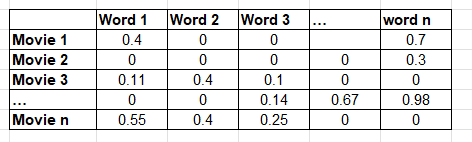

In [14]:
# Replace empty descriptions with a blank "" value and transform the titles of books in our dataset into the TF-IDF matrix
df['overview'] = df['overview'].fillna('')
tfidf_matrix = vectorizer.fit_transform(df['overview'])

tfidf_matrix.shape

(45466, 75827)

In [16]:
# There are 75827 words (not including stop words) used to describe the different movies
tfidf_matrix[0]

<1x75827 sparse matrix of type '<class 'numpy.float64'>'
	with 25 stored elements in Compressed Sparse Row format>

In [17]:
# Look at the vector representing the importance of the words in the document. Cumulatively, they represent the document.
print(tfidf_matrix[0])

  (0, 17764)	0.13483149538639247
  (0, 4388)	0.1474882034218405
  (0, 38030)	0.10142919482788751
  (0, 21887)	0.10438761058719498
  (0, 19641)	0.13281884272823927
  (0, 48558)	0.10339358185033234
  (0, 59519)	0.13008016104455086
  (0, 12490)	0.12544427954397822
  (0, 51108)	0.13434817283119177
  (0, 29238)	0.10093917370354445
  (0, 50914)	0.09190797940163035
  (0, 39423)	0.11907123344715953
  (0, 1847)	0.140911774178889
  (0, 58571)	0.1135591886873686
  (0, 38693)	0.20627924682810617
  (0, 9874)	0.5028038686135609
  (0, 9087)	0.10635375129287977
  (0, 7491)	0.12380553184830104
  (0, 56872)	0.111248510865236
  (0, 28729)	0.13311522181618415
  (0, 39012)	0.08718689178959059
  (0, 67874)	0.14878284660693247
  (0, 3159)	0.41178365711725945
  (0, 73468)	0.4809827114790237
  (0, 38088)	0.10739705953465473


### <font color = "blue"> Calculating Cosine similarity between the movie descriptions
Each row in the TF-IDF matrix represents a movie, so we can think of it as a vector. We calculate similarity by finding the angle between two movies, i.e. between two vectors. Also know as the dot product between two vectors, which results in a scalar representing it's similarity.

In [18]:
# Assign the instance of our recommender function.
# This is a matrix with a similarity value for every movie with every other movie in the dataset

from sklearn.metrics.pairwise import cosine_similarity
distance_matrix = cosine_similarity(tfidf_matrix)

# Re-create the indices of our list of movies by removing any duplicates if required
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [19]:
distance_matrix.size

2067157156

In [20]:
distance_matrix.shape

(45466, 45466)

In simpler form, it looks something like this:
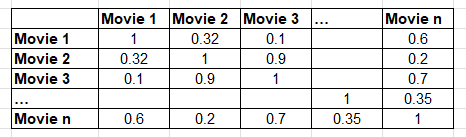

### <font color = "blue"> With Preprocessing and Matrix Calculations complete, fetch the most similar movies:

In [101]:
# Define a function that takes the re-indexed dataset, finds the 6 most similar titles 
#to a chosen title based on the
# similarity of the words in the titles,
# and returns the top 5, (not) including itself, which will be the best match. 

def ContentBasedRecommender(title, indices, distance_matrix):
    id_ = indices[title] #Fetch the index of the movie we will enter
    
    #List of tuples with distance for each movie to the entered movie (2 cols = id and distance)
    distances = list(enumerate(distance_matrix[id_])) 
    
    #sort by the distance function, which is in column[1]
    distances = sorted(distances, key=lambda x: x[1], reverse = True) 
    
    distances = distances[1:6] # Get the 5 best scores , not including itself
    #print(distances)
    
    # get the indices of the top 5
    recommendations = [distance[0] for distance in distances] 
    
    # return those recommendation names by pulling title from the given 5 indices
    return df['title'].iloc[recommendations] 

In [103]:
#Pick a title and see the resulting recommendations:
ContentBasedRecommender("The Dark Knight Rises", indices, distance_matrix)

12481               The Dark Knight
150                  Batman Forever
1328                 Batman Returns
15511    Batman: Under the Red Hood
585                          Batman
Name: title, dtype: object

In [105]:
# Try another one:
ContentBasedRecommender("Fight Club", indices,distance_matrix)

15461    9/11: The Twin Towers
31848           Unknown Caller
5203                 Delirious
23956           Make Your Move
22907                  In Fear
Name: title, dtype: object

In [121]:
#Test Random Movies! Note that only movies in the database can be referenced with this set-up!
# This code block has not been thoroughly tested! 
# i.e. It will throw an error if a movie title appears more than once in the database. There's room for improvement here!

import numpy as np

rand_movies_index = np.random.randint(low=0, high=len(df), size=1).astype(int)
print(rand_movies_index[0])

title = df["title"][rand_movies_index[0]]
print(title)

ContentBasedRecommender(title, indices, distance_matrix)



15183
The Good Heart


30976                          Dinosaur Island
31730                 Drifter: Henry Lee Lucas
25951    Excuse Me Darling, But Lucas Loved Me
4546                           Three Fugitives
24303               House III: The Horror Show
Name: title, dtype: object

### <font color = "blue"> Additional Info on NLP:

Are there other embedding techniques that could be used instead of TF-IDF?
<br>Sort of! There are other NLP techniques, but not widely used in this specific part of a recommender engine application.

The most similar would be Bag of Words. Each document is represented by a vector where each element corresponds to the count of a word in the document. This is really the only other prominent generic Vectorizer, but it is not commonly used in this method.

Word embeddings, such as Word2Vec, GloVe, (https://nlp.stanford.edu/projects/glove/) and FastText, represent words as dense, low-dimensional vectors in a continuous vector space. These assign specific pretrained vectors to the words, that can then be compared, but it may or may not have all the words required for your Corpus (Library). Like the names of all the characters in your movies! This is a commonly used technique in semantic and sentiment analysis, search engines, part-of-speech tagging, translating, chatbots and some parts of recommender engines. 
